# Initialize (non machine-specific parameters)

In [6]:
import pandas as pd # version 0.16.0 or later
import numpy as np
import datetime
import csv
from matplotlib import pyplot as plt
from datetime import datetime


def variablename(var):
    return [tpl[0] for tpl in
    filter(lambda x: var is x[1], globals().items())]

def get_df_name(df):
    name =[x for x in globals() if globals()[x] is df][0]
    return name
    #returns df's name to string

def get_df(str0):
    return globals()[str0]
    #returns df

colnames_base=",'epoch','seconds','zom','ch','fy','ref','i1','testfy','ctemp','i0','sc']"
Skiprow='14'
Epoch_offset=2133 #Epoch_132=Epoch_ssrl+2133


Scan_R_dict=[(390,440,'N'),(445,480,'Ti'),(455,490,'Ru'),(510,560,'O'),(620,680,'Mn'),(765,820,'Co'),(835,890,'Ni')]
Norm_L_dict=[(393,395,'N'),(453,454,'Ti'),(520,527,'O')]
Norm_H_dict=[(408,411,'N'),(468,469,'Ti'),(544,546,'O')]

belowedge=[393,395]
aboveedge=[408,411]


import math
stick_width=19.05
SampleX_min=0
SampleZ_min=455.5
R_cen=[(6,0,455.25),(6,0,455.25),(6,0,455.25),(6,0,454)]

def samplename_from_xyzr(df_sample,x,y,z,r):
    RR=r%90
    stick_width=19.05
    #X_cenRR=(df_sample['X_cen'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +1*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min
    df_sample['X_minR']=(df_sample['X_min'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min
    df_sample['X_maxR']=(df_sample['X_max'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min

    #samplename=df_sample[(df_sample['X_minR'] <= x) & (df_sample['X_maxR']  >= y)  &  (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["name"]
    #samplename=df_sample[(X_minRR <= x) & (X_maxRR  >= y)  &  (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["name"]
    samplename=df_sample[ (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["SAMPLE"]

    if len(samplename)!=0:
        return(samplename.tolist()[0])
    elif z < SampleZ_min:
        return('photodiode')
    else:
        return(None)

def sampleid_from_xyzr(df_sample,x,y,z,r):

    RR=r%90
    stick_width=19.05
    df_sample['X_minR']=(df_sample['X_min'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min
    df_sample['X_maxR']=(df_sample['X_max'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min

    #sampleid=df_sample[(df_sample['X_minR'] <= x) & (df_sample['X_maxR']  >= x)  &  (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["Sample_ID"]
    sampleid=df_sample[(df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["ID"]

    if len(sampleid)!=0:
        return(sampleid.tolist()[0])
    else:
        return(None)

def scanstring_from_mono132(M0):
    for i in range(len(Scan_R_dict)):
        if ((M0 <= float(Scan_R_dict[i][1])) &  (M0 >= float(Scan_R_dict[i][0]))):
            return(Scan_R_dict[i][2])
    return('')

def normlow_from_scanstring(M0):
    for i in range(len(Norm_L_dict)):
        if ((M0 == (Norm_L_dict[i][2]))):
            return(Norm_L_dict[i][0],Norm_L_dict[i][1])
    return('')
def normhigh_from_scanstring(M0):
    for i in range(len(Norm_H_dict)):
        if ((M0 ==(Norm_H_dict[i][2]))):
            return(Norm_H_dict[i][0],Norm_H_dict[i][1])
    return('')

import os


# Initiualize (machine specific parameters)

In [3]:
# This is the configuration to analyze files on Local Drive
# Need to copy data files to Local Drive
data_foldername='20250627'
experiment=["20250627"] #list

mydrive_path='/Users/hirohito/data/'
home=mydrive_path+data_foldername+'/'
DirSeparator='/'
os.chdir(home)
dir = home+"pandas"
if not os.path.exists(dir):
    os.makedirs(dir)

# This is the configuration to analyze files using Google Collab + Google Drive
# Need to copy data files under MyDrive
from google.colab import drive
drive.mount('/content/gdrive')
mydrive_path='/content/gdrive/MyDrive/'
data_foldername='SSRL_BL132/6739/data/'
home=mydrive_path+data_foldername
DirSeparator='/'
os.chdir(home)
dir = home+"pandas"
if not os.path.exists(dir):
    os.makedirs(dir)

In [5]:
#htxs_commnets purser
#Not needed
colnames_sample=['Epoch','C01','C02','C03','C04','C05','C06','C07','C08','Scan_number','Scan_type','C09','C10','Sample_position','C11','C12','C13','C14','Column_id','C15','Row_id','Sample_id','Sample_name']
inputFile=home+'htxs_comments'
inputFile=home+'htxs_comments'
df_sample = pd.read_csv(inputFile, names=colnames_sample, header=None,sep=' ')

for i, j in df_sample.iterrows():
    #print(j.iloc[2],j.iloc[3],j.iloc[4],int(j.iloc[5]))
    date_string = str(int(j.iloc[5]))+'-'+str(j.iloc[2])+'-'+str(j.iloc[3])+' '+str(j.iloc[4])
    #print(df_sample.iloc[0:2])
    date_format = "%Y-%M-%d %H:%M:%S"
    date_object = datetime.strptime(str(j.iloc[2]), "%b")
    year_number=int(j.iloc[5])
    month_number = date_object.month
    date_number=int(j.iloc[3])
    date_object = datetime.strptime(str(j.iloc[4]), "%H:%M:%S")
    hour_number = date_object.hour
    minute_number = date_object.minute
    second_number = date_object.second
    #print(hour_number, minute_number,second_number)

    #from datetime import datetime
    dt = datetime(year_number, month_number, date_number, hour_number, minute_number,second_number)

    epoch_time = dt.timestamp()
    df_sample.iloc[i,0]=epoch_time-Epoch_offset
    j.iloc[0]=epoch_time
    #print(j.iloc[0],epoch_time)


# XAS

In [16]:
!rsync -av --bwlimit=1M bl132lx:~/data/20250627 ~/data

Transfer starting: 913 files
20250627/
20250627/htxs_comments
20250627/spec/
20250627/spec/htxs
20250627/spec/htxs_scan469.csv
20250627/spec/htxs_scan470.csv
20250627/spec/htxs_scan471.csv
20250627/spec/htxs_scan472.csv
20250627/spec/htxs_scan473.csv
20250627/spec/htxs_scan474.csv
20250627/spec/htxs_scan475.csv
20250627/spec/htxs_scan476.csv
20250627/spec/htxs_scan477.csv
20250627/spec_alias/
20250627/spec_alias/xc1s_d15_z6.5_Ir_Gr_Ag1_469 -> ../spec/htxs_scan469.csv
20250627/spec_alias/xc1s_d15_z6.5_Ir_Gr_Ag1_470 -> ../spec/htxs_scan470.csv
20250627/spec_alias/xc1s_d15_z6.5_Ir_Gr_Ag1_471 -> ../spec/htxs_scan471.csv
20250627/spec_alias/xc1s_d15_z6.5_Ir_Gr_Ag1_472 -> ../spec/htxs_scan472.csv
20250627/spec_alias/xc1s_d15_z6.5_Ir_Gr_Ag1_473 -> ../spec/htxs_scan473.csv
20250627/spec_alias/xc1s_d15_z6.5_Ir_Gr_Ag1_474 -> ../spec/htxs_scan474.csv
20250627/spec_alias/xc1s_d15_z6_Ir_Gr_Ti2_475 -> ../spec/htxs_scan475.csv
20250627/spec_alias/xc1s_d15_z6_Ir_Gr_Ti2_476 -> ../spec/htxs_scan476.csv


In [8]:
load_list=[]
for _experiment in experiment:
    pathstr=home+'/spec_alias/'
    for x in os.listdir(pathstr):
        load_list.append(x)
load_list.sort()
dir = home+"plots"
if not os.path.exists(dir):
    os.makedirs(dir)

In [12]:
df_X = pd.DataFrame()
for k in load_list:
    colnameslist = ["Sample","mono132",  "Seconds", "I0", "SC","ZOM", "CH","FY","REF", "I1", "testfy", "CTEMP"]   
    df_temp=pd.read_csv(home+"/spec_alias/" +k,comment='#',names=colnameslist,sep=',',skiprows=1)
    df_temp['Sample']=k
    #df_X=appended_df = pd.concat([df_X, df_temp], ignore_index=True)
    df_X= pd.concat([df_X, df_temp], ignore_index=True)
df_X.to_csv(home+'pandas/'+'specdatafrane.csv', index=False) 

In [14]:
df_temp

,Sample,mono132,Seconds,I0,SC,ZOM,CH,FY,REF,I1,testfy,CTEMP
0,xc1s_d15_z6_Ir_Gr_Ti2_476,279.001,0.9,15027,40949,7545,0,4017,148,1035,260.1,0
1,xc1s_d15_z6_Ir_Gr_Ti2_476,279.200,0.9,15329,41773,7576,0,4025,149,1041,290.7,0
2,xc1s_d15_z6_Ir_Gr_Ti2_476,279.400,0.9,15157,41327,7541,0,4018,149,1038,266.4,0
3,xc1s_d15_z6_Ir_Gr_Ti2_476,279.601,0.9,15139,41343,7518,0,4014,148,1041,256.5,0
4,xc1s_d15_z6_Ir_Gr_Ti2_476,279.799,0.9,15325,41870,7562,0,4036,150,1043,284.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
224,xc1s_d15_z6_Ir_Gr_Ti2_476,313.999,0.9,104680,499399,7584,0,5746,150,2597,867.6,0
225,xc1s_d15_z6_Ir_Gr_Ti2_476,314.250,0.9,104990,477719,7574,0,5742,151,2618,900.0,0
226,xc1s_d15_z6_Ir_Gr_Ti2_476,314.501,0.9,102668,470020,7569,0,5703,151,2581,855.0,0
227,xc1s_d15_z6_Ir_Gr_Ti2_476,314.750,0.9,100564,480872,7571,0,5619,152,2541,882.9,0


SC=df_X[df_X['Sample']=='xc1s_d15_z5_III_S1_185']['SC']
I0=df_X[df_X['Sample']=='xc1s_d15_z5_III_S1_185']['I0']
X=df_X[df_X['Sample']=='xc1s_d15_z5_III_S1_185']['mono132']
Y=SC/I0

In [39]:
df_temp.columns

Index(['mono132', 'SC_I0normd'], dtype='object')

/var/folders/s_/fqjgzzf16vn2ptt52spvkm_959ty5z/T/ipykernel_23323/1961861883.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


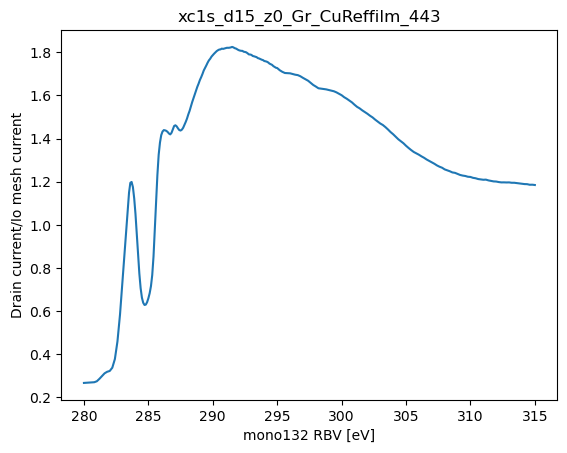

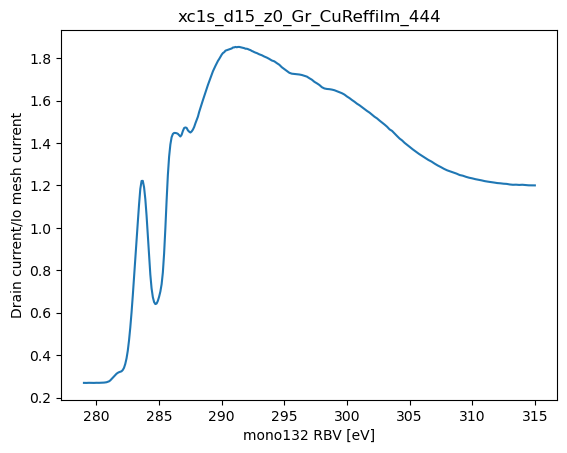

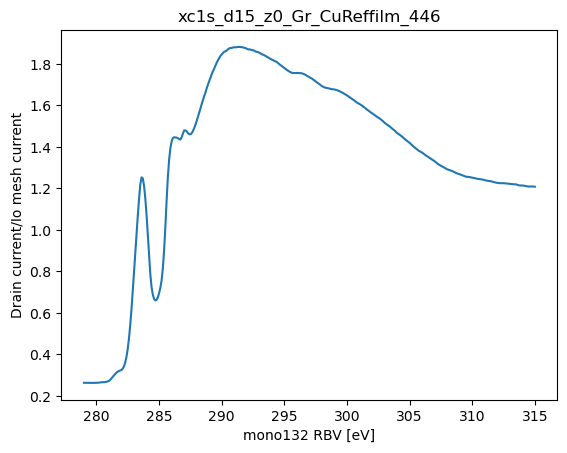

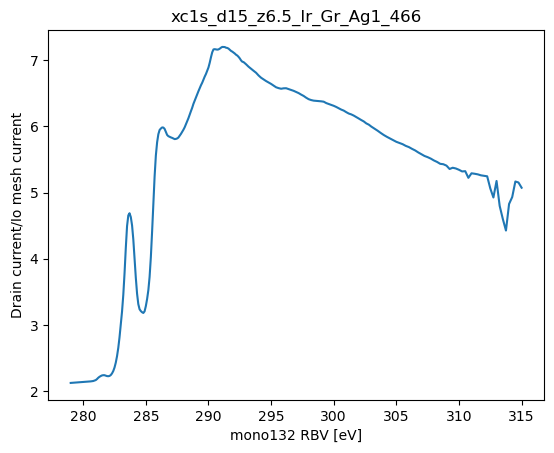

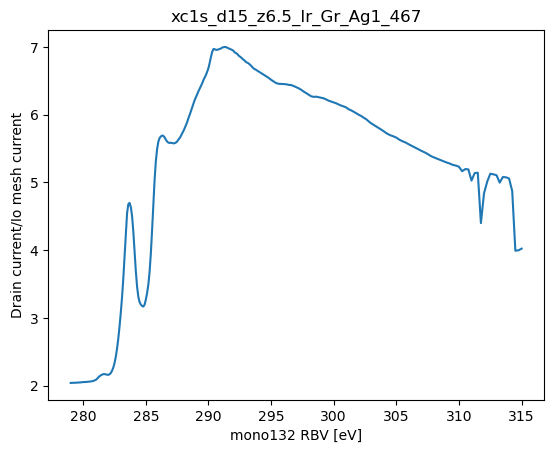

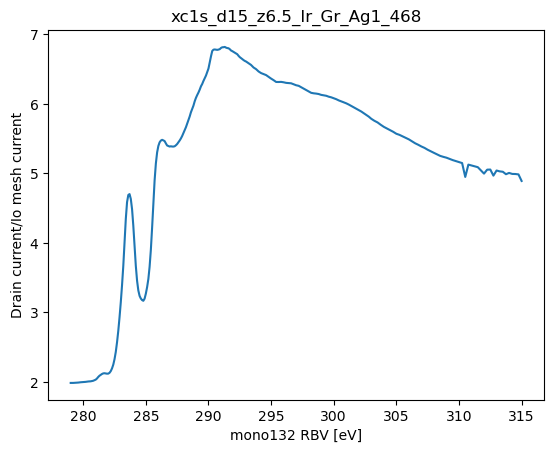

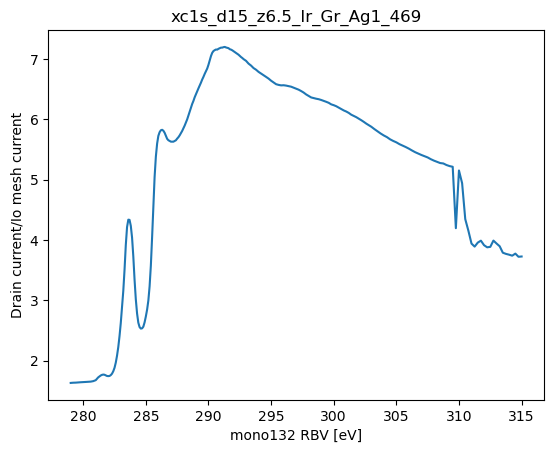

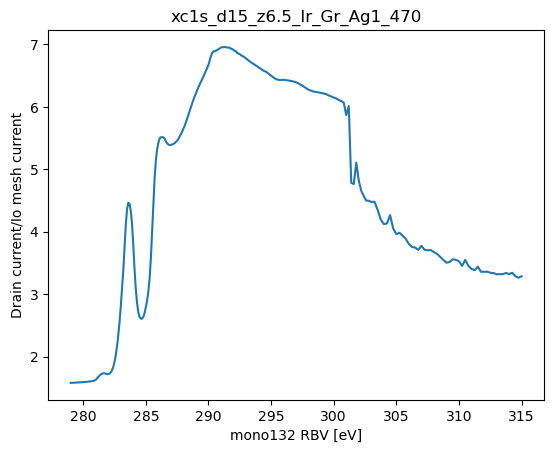

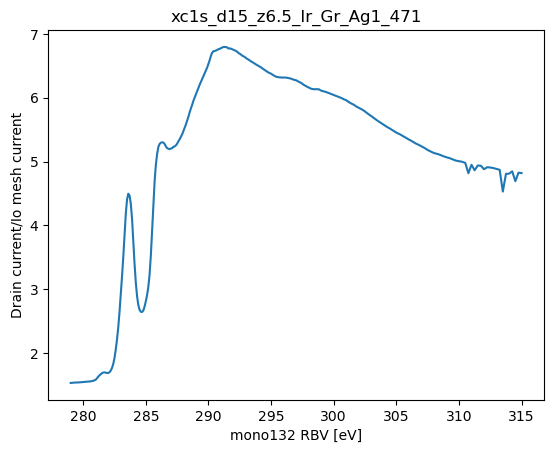

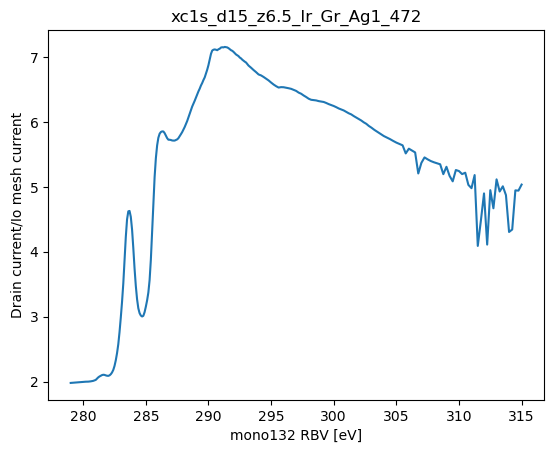

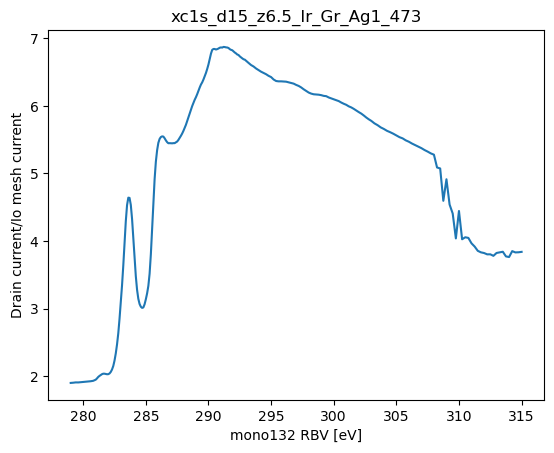

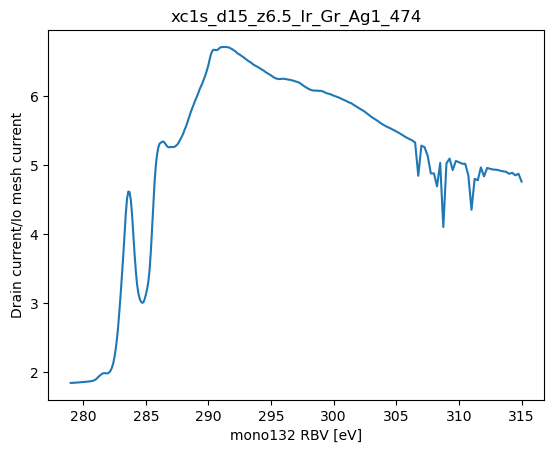

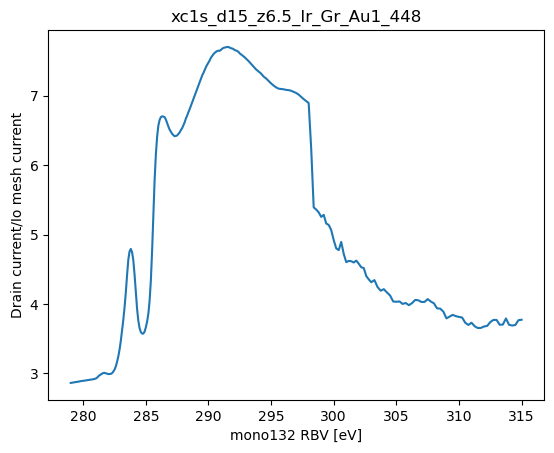

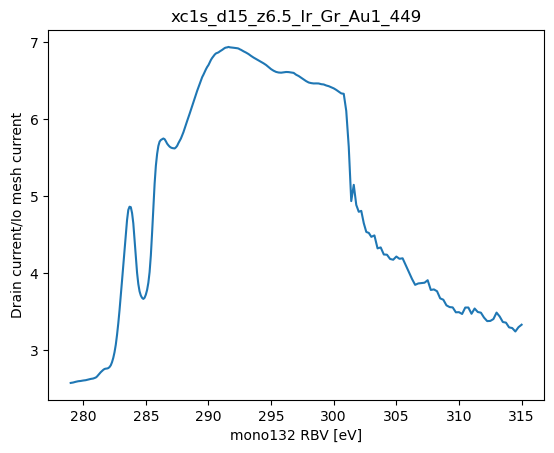

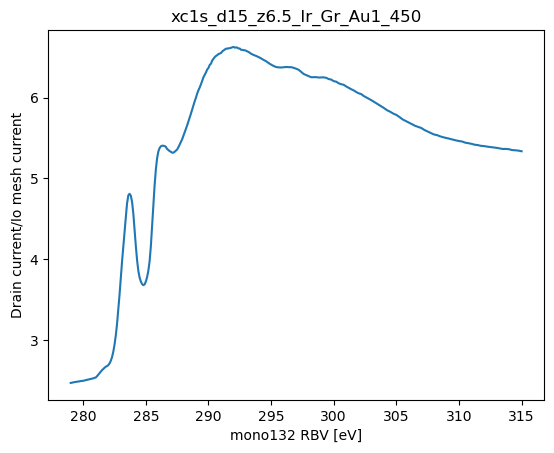

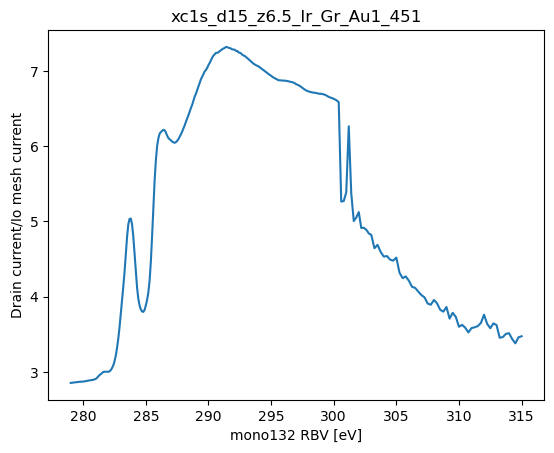

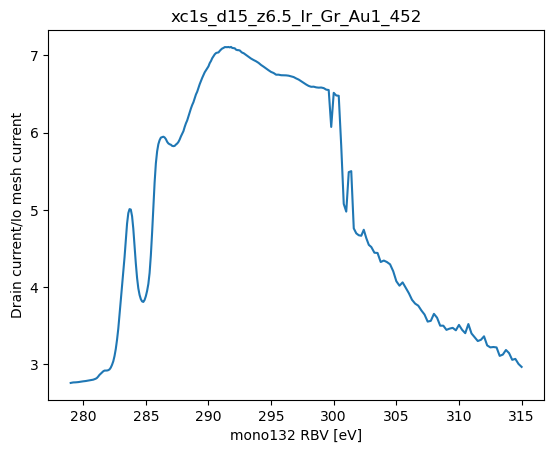

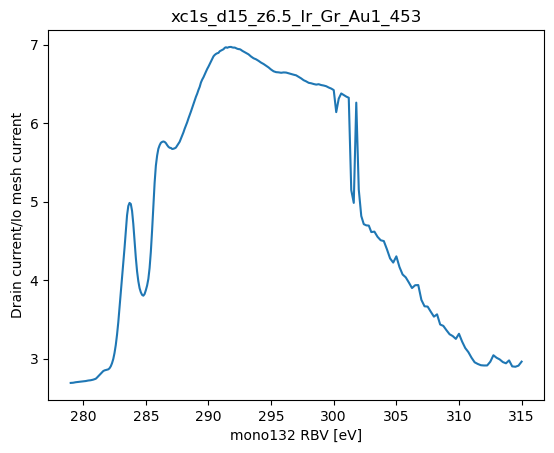

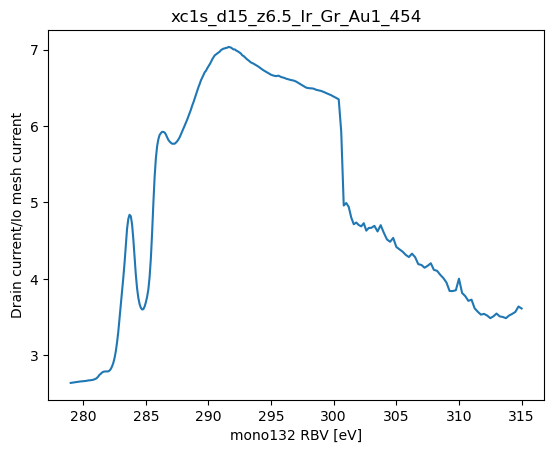

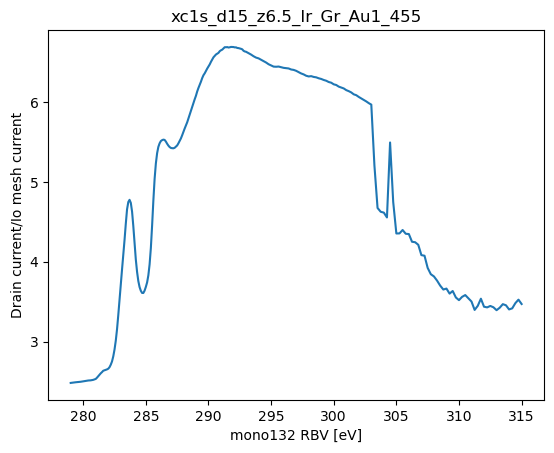

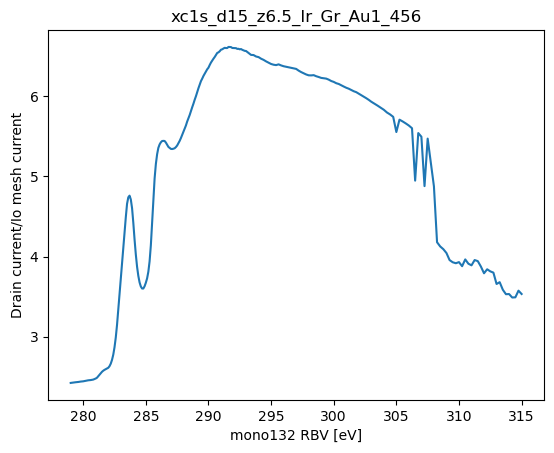

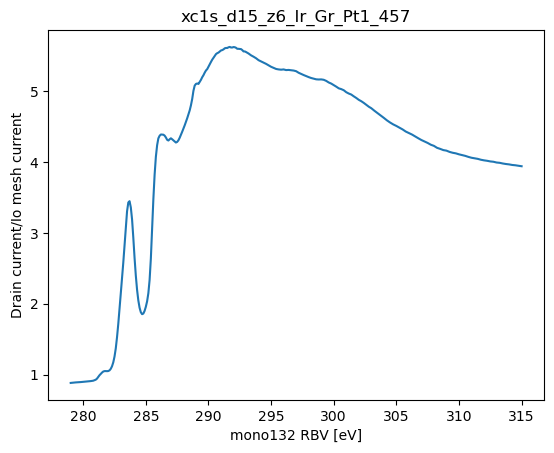

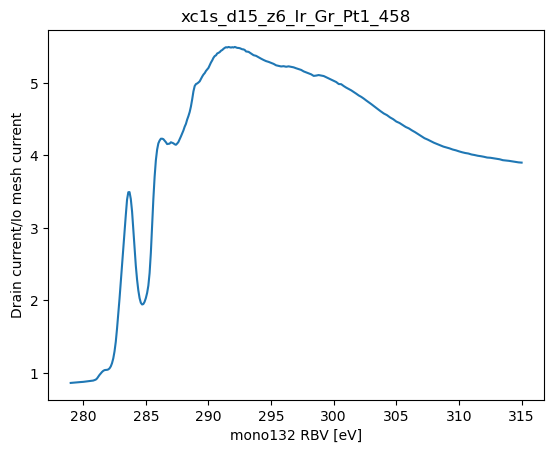

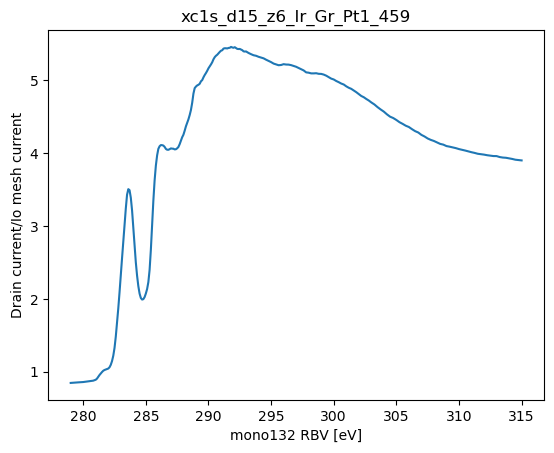

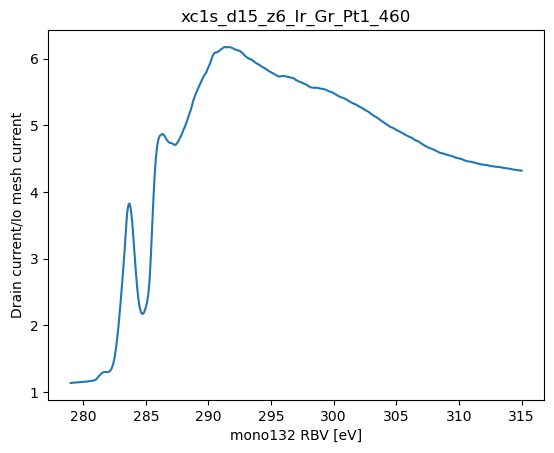

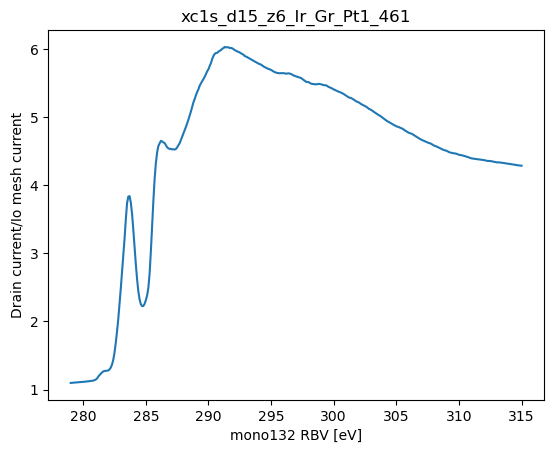

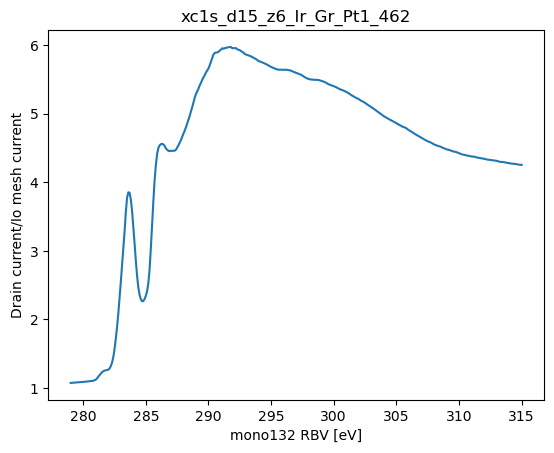

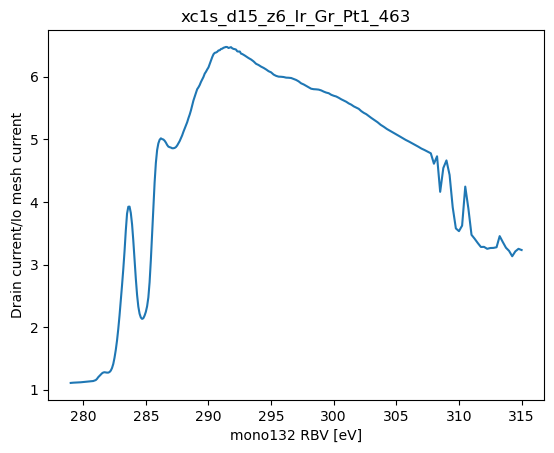

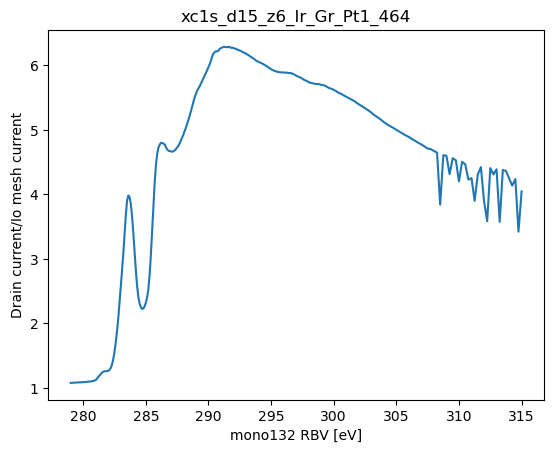

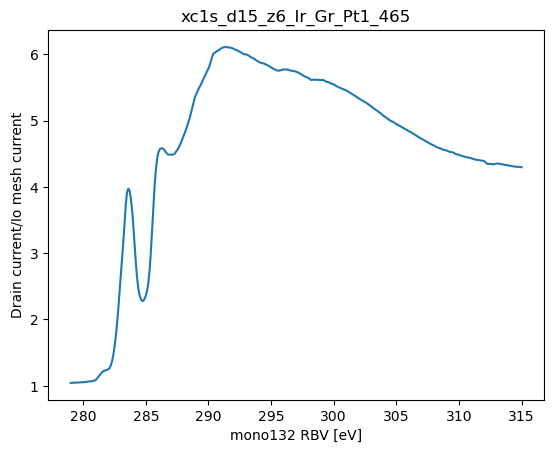

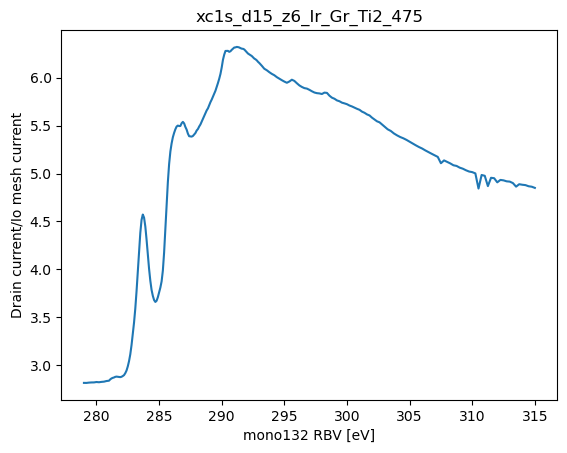

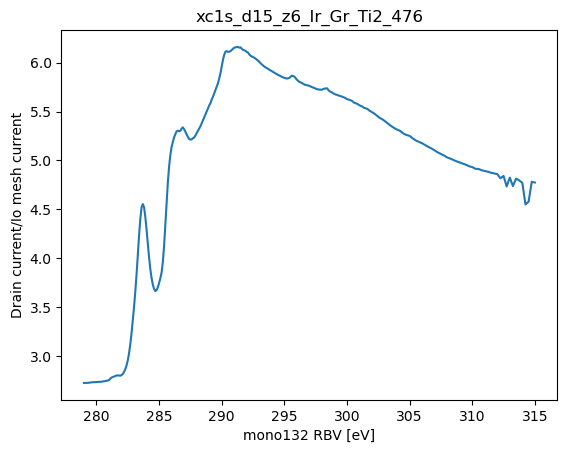

<Figure size 640x480 with 0 Axes>

In [42]:
i=0
for k in load_list:
    savefilename=home+'plots/'+k+'.pdf'
    SC=df_X[df_X['Sample']==k]['SC']
    FY=df_X[df_X['Sample']==k]['FY']
    I0=df_X[df_X['Sample']==k]['I0']
    X=df_X[df_X['Sample']==k]['mono132']
    Y=SC/I0
    df_temp=pd.concat([X,Y],axis=1)
    col_label='SC_I0normd'
    df_temp=df_temp.rename(columns={0: col_label})
    df_temp.to_csv(home+'pandas/'+k+col_label+'.csv',index=False)
    if 'xc1s' in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:
       plt.plot(X,Y)
       plt.title(k)
       plt.ylabel('Drain current/Io mesh current')
       plt.xlabel('mono132 RBV [eV]')
    #plt.show()    
       plt.savefig(savefilename)
       #i=i+1
       #plt.legend()
       plt.show
       plt.figure()

        
       

In [36]:
df_temp

,mono132,0
47072,279.001,2.725028
47073,279.200,2.725096
47074,279.400,2.726595
47075,279.601,2.730894
47076,279.799,2.732137
...,...,...
47296,313.999,4.770720
47297,314.250,4.550138
47298,314.501,4.578057
47299,314.750,4.781751


In [ ]:
i=0
for k in load_list:
    savefilename=home+'plots/'+k+'.pdf'
    SC=df_X[df_X['Sample']==k]['SC']
    FY=df_X[df_X['Sample']==k]['FY']
    I0=df_X[df_X['Sample']==k]['I0']
    X=df_X[df_X['Sample']==k]['mono132']
    Y=SC/I0

    if 'xc1s' in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:
       plt.plot(X,Y)
       plt.title(k)
       plt.ylabel('Drain current/Io mesh current')
       plt.xlabel('mono132 RBV [eV]')
    #plt.show()    
       plt.savefig(savefilename)
       #i=i+1
       plt.show
       if k !=k0:
          plt.figure()
    k0=k
        
       


In [ ]:
 pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]